# 05 — Approach II rule-based typing (interactive, versioned)

This notebook is designed for parameter experiments. Change `MIN_POSITIVE_GENES` (e.g. 2, 3, 4), rerun the rule, and each saved result receives a distinct tag so previous results are never overwritten.

In [20]:
# ============================================================
# Dataset_02 CosMx — shared Jupyter initialization
# ============================================================
from pathlib import Path
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

CURRENT_DIR = Path.cwd().resolve()

def find_project_root(start: Path) -> Path:
    """Find the nearest parent containing both src/ and data/."""
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not locate project root from {start}. "
        "Expected a parent containing src/ and data/."
    )

PROJECT_ROOT = find_project_root(CURRENT_DIR)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SPATIAL_DIR = PROJECT_ROOT / "data" / "spatial"
RESULTS_DIR = PROJECT_ROOT / "results"
CONFIG_DIR = PROJECT_ROOT / "config"

sc.settings.verbosity = 2

print("=" * 70)
print("Dataset_02 CosMx Jupyter environment")
print("=" * 70)
print("Notebook directory :", CURRENT_DIR)
print("Project root       :", PROJECT_ROOT)
print("Python             :", sys.executable)
print("src exists         :", (PROJECT_ROOT / "src").exists())
print("raw data exists    :", RAW_DIR.exists())
print("processed exists   :", PROCESSED_DIR.exists())
print("spatial exists     :", SPATIAL_DIR.exists())


Dataset_02 CosMx Jupyter environment
Notebook directory : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/jupyter-2
Project root       : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised
Python             : /home/jqu/.conda/envs/spatialdata/bin/python
src exists         : True
raw data exists    : True
processed exists   : True
spatial exists     : True


In [21]:
from scipy import sparse
from config.markers import MARKER_PANEL
from src.typing import detection_rate

# ============================================================
# Approach-I input selection — EDIT HERE
# ============================================================
USE_APPROACH_I_VARIANT = False
APPROACH_I_TAG = "r0.6_manual"
APPROACH_I_VARIANT = RESULTS_DIR / "FOV46" / "approach_i_variants" / APPROACH_I_TAG / f"GSM9046088_FOV46_approach_i_{APPROACH_I_TAG}.h5ad"
APPROACH_I_PRODUCTION = RESULTS_DIR / "FOV46" / "GSM9046088_FOV46_approach_i.h5ad"
APPROACH_I_INPUT = APPROACH_I_VARIANT if USE_APPROACH_I_VARIANT else APPROACH_I_PRODUCTION

print("Approach-I input:", APPROACH_I_INPUT)
print("Exists          :", APPROACH_I_INPUT.exists())
if not APPROACH_I_INPUT.exists():
    raise FileNotFoundError(APPROACH_I_INPUT)

a = sc.read_h5ad(APPROACH_I_INPUT)
print(a)
print("Approach I labels:", a.obs["cell_type_scanpy"].value_counts())


Approach-I input: /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/GSM9046088_FOV46_approach_i.h5ad
Exists          : True
AnnData object with n_obs × n_vars = 938 × 1000
    obs: 'fov', 'cell_ID', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.B2M.MembraneStain', 'Max.B2M.MembraneStain', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'n_genes_by_counts', 'total_counts', 'control_counts', 'control_fraction', 'qc_cell_area', 'qc_low_count_within_fov', 'qc_low_gene_within_fov', 'qc_pass', 'leiden_r0.1', 'leiden_r0.2', 'leiden_r0.3', 'leiden_r0.4', 'leiden_r0.5', 'leiden_r0.6', 'leiden_r0.7', 'leiden_r0.8', 'leiden_r0.9', 'leiden_r1', 'leiden', 'cell_type_scanpy'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'is_

## Experiment parameter
`RUN_TAG` defaults to `min3`, `min2`, etc. You can add a descriptive suffix such as `min3_v2`.

In [13]:
# ============================================================
# Rule-based sensitivity parameter — EDIT AND RERUN CELLS BELOW
# ============================================================
MIN_POSITIVE_GENES = 3
RUN_TAG = f"min{MIN_POSITIVE_GENES}"   # e.g. min2, min3, min4, min3_testA
LAYER = "counts"
RULE_COL = f"cell_type_rule_{RUN_TAG}"

print("Rule     : >=", MIN_POSITIVE_GENES, "available marker genes with raw count > 0")
print("RUN_TAG  :", RUN_TAG)
print("RULE_COL :", RULE_COL)


Rule     : >= 3 available marker genes with raw count > 0
RUN_TAG  : min3
RULE_COL : cell_type_rule_min3


In [14]:
# Marker availability and detection rates.
rates=[]; availability=[]; positives={}; n_positive_by_type={}
Xall=a.layers[LAYER]
for cell_type, genes in MARKER_PANEL.items():
    present=[g for g in genes if g in a.var_names]
    missing=[g for g in genes if g not in a.var_names]
    available=len(present)>=MIN_POSITIVE_GENES
    availability.append(dict(cell_type=cell_type,n_requested=len(genes),n_present=len(present),min_positive_genes=MIN_POSITIVE_GENES,available=available,present=",".join(present),missing=",".join(missing)))
    for gene,value in detection_rate(a,genes,layer=LAYER).items(): rates.append(dict(cell_type=cell_type,gene=gene,detection_rate=value))
    if not available:
        positives[cell_type]=np.zeros(a.n_obs,dtype=bool); n_positive_by_type[cell_type]=np.zeros(a.n_obs,dtype=int); continue
    idx=[a.var_names.get_loc(g) for g in present]; x=Xall[:,idx]
    x=x.toarray() if sparse.issparse(x) else np.asarray(x)
    npos=np.asarray((x>0).sum(axis=1)).ravel()
    n_positive_by_type[cell_type]=npos
    positives[cell_type]=npos>=MIN_POSITIVE_GENES

availability_df=pd.DataFrame(availability)
display(availability_df)

,cell_type,n_requested,n_present,min_positive_genes,available,present,missing
0,Epithelial,4,4,3,True,"EPCAM,KRT8,KRT18,KRT19",
1,AT1,4,1,3,False,CAV1,"AGER,CAV2,PDPN"
2,AT2,5,0,3,False,,"SFTPA1,SFTPA2,SFTPB,SFTPC,NAPSA"
3,Tumor_epithelial,5,3,3,True,"CEACAM6,KRT17,MKI67","CEACAM5,MUC1"
4,T_cell,4,2,3,False,"CD3D,CD3E","TRAC,CD247"
5,B_cell,4,3,3,True,"MS4A1,CD79A,CD37",CD79B
6,Plasma_cell,4,3,3,True,"MZB1,JCHAIN,IGHG1",SDC1
7,Myeloid,4,3,3,True,"TYROBP,FCER1G,AIF1",LST1
8,Macrophage,5,5,3,True,"C1QA,C1QB,C1QC,APOE,CD68",
9,Endothelial,4,3,3,True,"PECAM1,VWF,KDR",EMCN


In [15]:
# Assign Unassigned / one cell type / Ambiguous.
cell_types=list(MARKER_PANEL)
mat=np.column_stack([positives[ct] for ct in cell_types])
n_panels=mat.sum(axis=1)
labels=np.full(a.n_obs,"Unassigned",dtype=object)
one=n_panels==1
labels[one]=np.asarray(cell_types,dtype=object)[mat[one].argmax(axis=1)]
labels[n_panels>1]="Ambiguous"

RULE_COL=f"cell_type_rule_{RUN_TAG}"
a.obs[RULE_COL]=pd.Categorical(labels)
a.obs[f"rule_n_positive_panels_{RUN_TAG}"]=n_panels
for ct in cell_types:
    a.obs[f"rule_{ct}_n_positive_genes_{RUN_TAG}"]=n_positive_by_type[ct]

print("RULE_COL:",RULE_COL)
display(a.obs[RULE_COL].value_counts(dropna=False))

RULE_COL: cell_type_rule_min3


cell_type_rule_min3
Unassigned     331
Ambiguous      176
Macrophage     159
Plasma_cell    117
Fibroblast      91
Epithelial      63
Endothelial      1
Name: count, dtype: int64

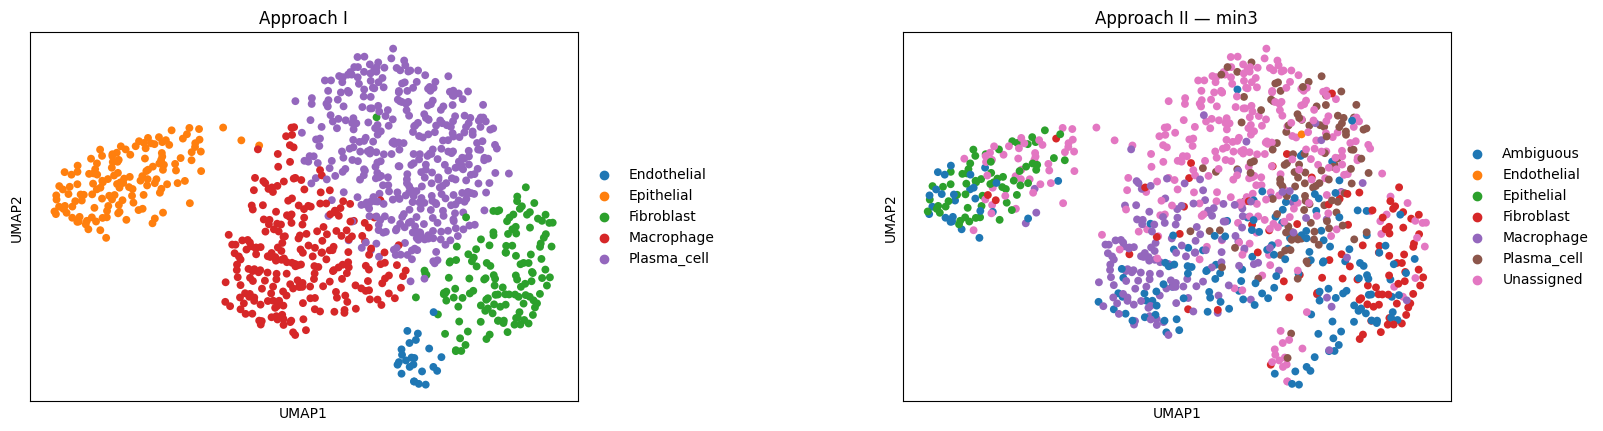

In [16]:
# UMAP — same coordinates/theme as Approach I.
sc.pl.umap(a,color=["cell_type_scanpy",RULE_COL],frameon=True,wspace=.45,legend_loc="right margin",title=["Approach I",f"Approach II — {RUN_TAG}"])

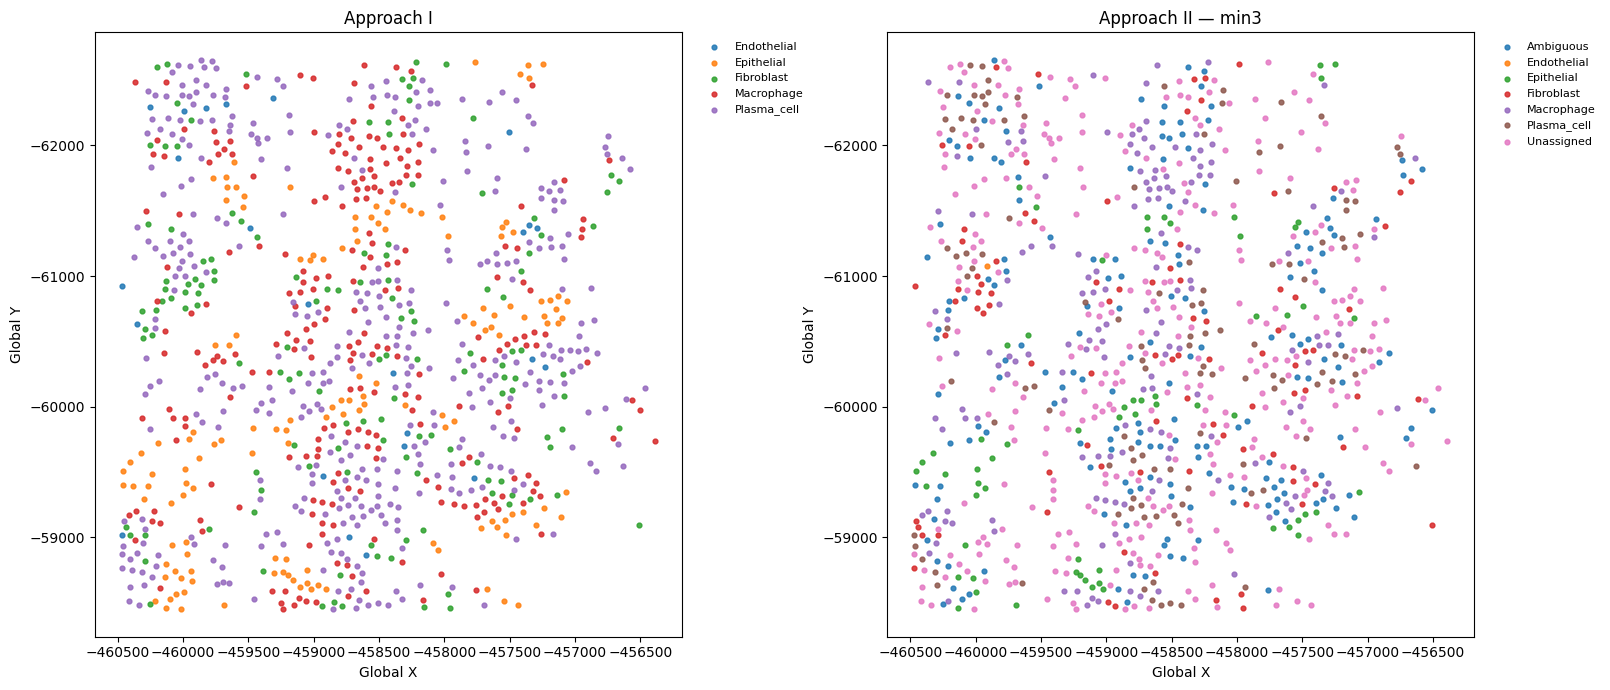

In [17]:
# Spatial coordinate comparison.
xy=np.asarray(a.obsm["spatial"])
fig,axes=plt.subplots(1,2,figsize=(16,7))
for ax,col,title in zip(axes,["cell_type_scanpy",RULE_COL],["Approach I",f"Approach II — {RUN_TAG}"]):
    lab=a.obs[col].astype("category")
    for cat in lab.cat.categories:
        m=lab.astype(str).to_numpy()==str(cat); ax.scatter(xy[m,0],xy[m,1],s=12,label=str(cat),alpha=.85)
    ax.set_aspect("equal");ax.invert_yaxis();ax.set_xlabel("Global X coordinate (px)");ax.set_ylabel("Global Y coordinate (px)");ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02,1),loc="upper left",frameon=False,fontsize=8)
plt.tight_layout();plt.show()

In [18]:
# Quick Approach-I × current Approach-II contingency table.
ct=pd.crosstab(a.obs["cell_type_scanpy"],a.obs[RULE_COL])
frac=pd.crosstab(a.obs["cell_type_scanpy"],a.obs[RULE_COL],normalize="index")
display(ct); display(frac.round(3))

cell_type_rule_min3,Ambiguous,Endothelial,Epithelial,Fibroblast,Macrophage,Plasma_cell,Unassigned
cell_type_scanpy,,,,,,,
Endothelial,7,0,0,1,0,2,14
Epithelial,26,0,63,3,3,0,46
Fibroblast,51,0,0,63,5,2,16
Macrophage,59,0,0,8,128,5,42
Plasma_cell,33,1,0,16,23,108,213


cell_type_rule_min3,Ambiguous,Endothelial,Epithelial,Fibroblast,Macrophage,Plasma_cell,Unassigned
cell_type_scanpy,,,,,,,
Endothelial,0.292,0.000,0.000,0.042,0.000,0.083,0.583
Epithelial,0.184,0.000,0.447,0.021,0.021,0.000,0.326
Fibroblast,0.372,0.000,0.000,0.460,0.036,0.015,0.117
Macrophage,0.244,0.000,0.000,0.033,0.529,0.021,0.174
Plasma_cell,0.084,0.003,0.000,0.041,0.058,0.274,0.541


## Save this experiment without overwriting earlier runs
Outputs include `RUN_TAG` in the filename/directory. You can therefore save `min2`, `min3`, `min4`, etc. and compare them later.

In [19]:
# ============================================================
# Versioned Approach-II output
# ============================================================
SAVE_APPROACH_II = False
APPROACH_II_OUTPUT_DIR = RESULTS_DIR / "FOV46" / "approach_ii_variants" / RUN_TAG
APPROACH_II_OUTPUT_FILE = APPROACH_II_OUTPUT_DIR / f"GSM9046088_FOV46_approach_i_ii_{RUN_TAG}.h5ad"
FIG_OUTPUT_DIR = APPROACH_II_OUTPUT_DIR / "figures"
TAB_OUTPUT_DIR = APPROACH_II_OUTPUT_DIR / "tables"

print("SAVE_APPROACH_II :", SAVE_APPROACH_II)
print("Output directory :", APPROACH_II_OUTPUT_DIR)
print("Output filename  :", APPROACH_II_OUTPUT_FILE.name)
print("Full output path :", APPROACH_II_OUTPUT_FILE)
print("Currently exists :", APPROACH_II_OUTPUT_FILE.exists())

if SAVE_APPROACH_II:
    FIG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    TAB_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    a.write_h5ad(APPROACH_II_OUTPUT_FILE, compression="gzip")
    pd.DataFrame(availability).to_csv(TAB_OUTPUT_DIR / f"rule_marker_availability_{RUN_TAG}.csv", index=False)
    pd.DataFrame(rates).to_csv(TAB_OUTPUT_DIR / f"rule_marker_detection_rates_{RUN_TAG}.csv", index=False)
    a.obs[RULE_COL].value_counts(dropna=False).to_csv(TAB_OUTPUT_DIR / f"rule_label_counts_{RUN_TAG}.csv")
    print("Saved:", APPROACH_II_OUTPUT_FILE)
else:
    print("SAVE_APPROACH_II=False — current rule result remains in memory only.")


SAVE_APPROACH_II : False
Output directory : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/approach_ii_variants/min3
Output filename  : GSM9046088_FOV46_approach_i_ii_min3.h5ad
Full output path : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/approach_ii_variants/min3/GSM9046088_FOV46_approach_i_ii_min3.h5ad
Currently exists : False
SAVE_APPROACH_II=False — current rule result remains in memory only.
